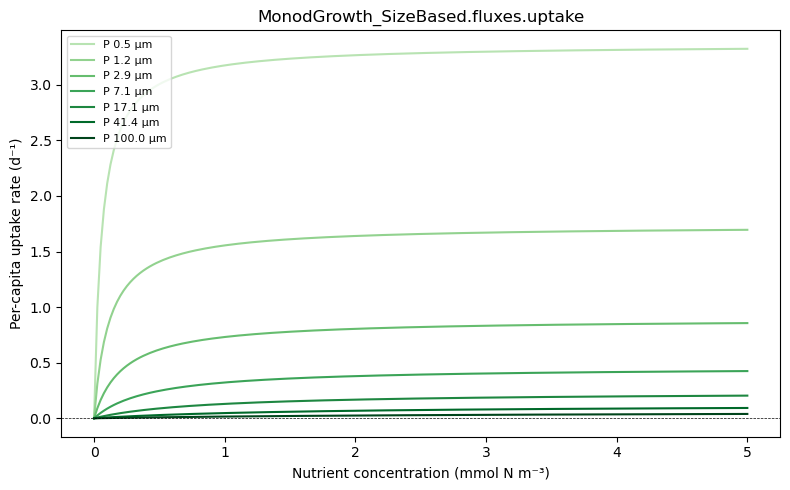

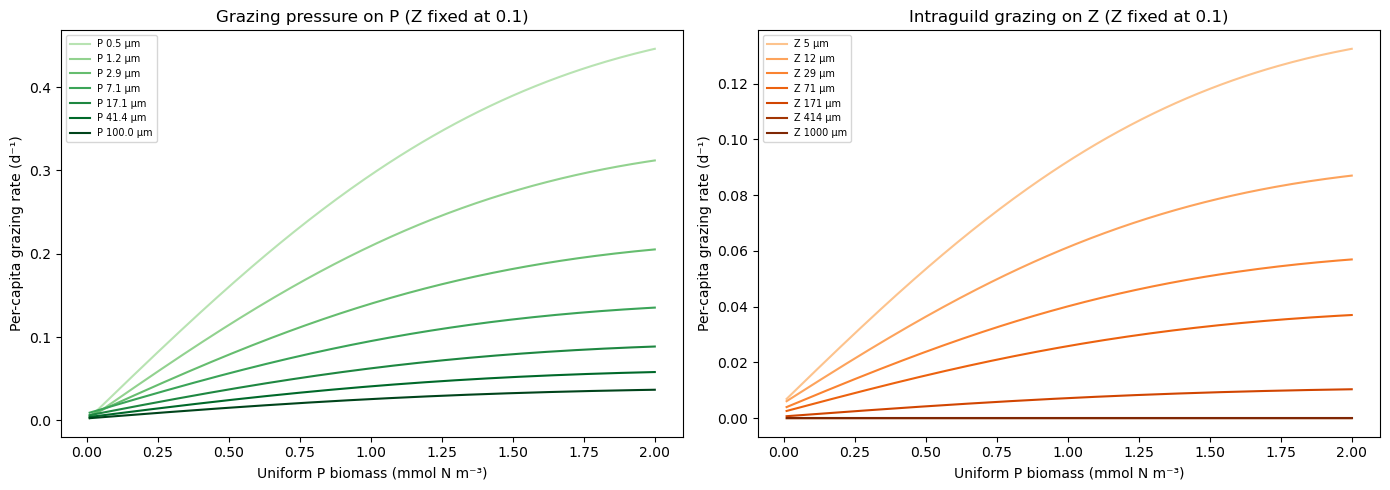

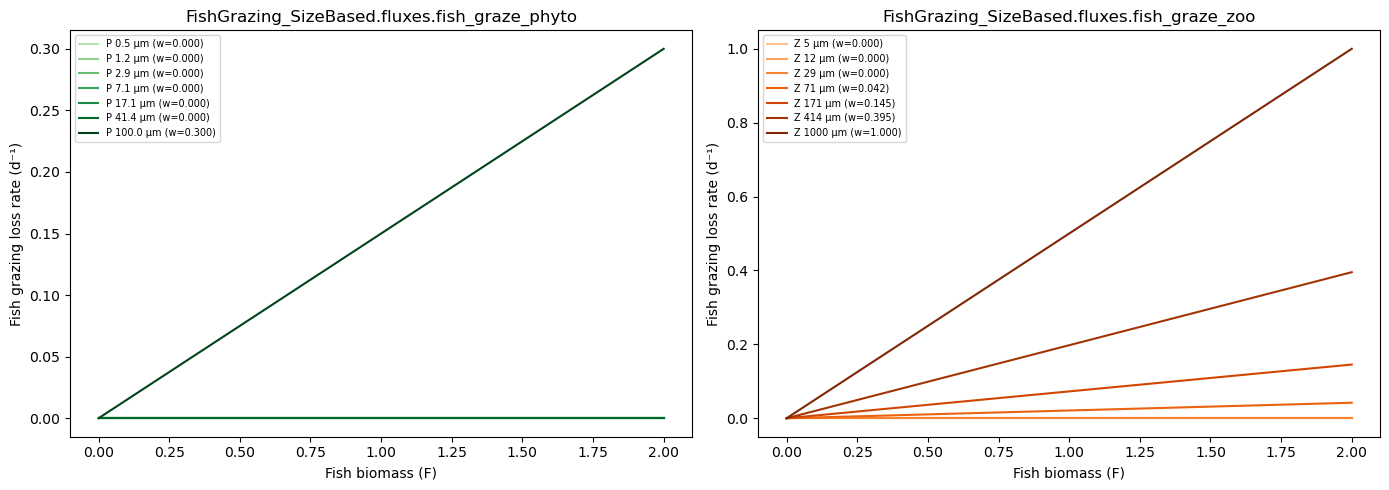

Done. Saved: fluxes_1-3_*.png


In [1]:
"""
Diagnostic trade-off plots using Component.fluxes namespace
============================================================
Calls flux functions directly from imported XSO components.
"""

import numpy as np
import matplotlib.pyplot as plt

from npxzxf_comps import (
    MonodGrowth_SizeBased,
    SizebasedGrazingMatrix_Full_TypeIII,
    FishGrazing_SizeBased,
)
from npxzxf_models import (
    phyto_esd, zoo_esd,
    mu_max, K_s, m_P,
    I_max, m_Z,
    phiPZ, w_P, w_Z,
    BASE_INPUT_VARS,
)

n_P = len(phyto_esd)
n_Z = len(zoo_esd)
KsZ = BASE_INPUT_VARS['Grazing']['KsZ']
fish_rate = BASE_INPUT_VARS['FishGrazing']['rate']

cmap_P = plt.cm.Greens(np.linspace(0.3, 1.0, n_P))
cmap_Z = plt.cm.Oranges(np.linspace(0.3, 1.0, n_Z))


# =====================================================================
# PLOT 1: Nutrient uptake (Monod growth) vs N
# =====================================================================
N_range = np.linspace(0, 5, 200)

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(n_P):
    # call the flux for a single size class: scalar consumer = 1 → per-capita rate
    rate = MonodGrowth_SizeBased.fluxes.uptake(
        resource=N_range,
        consumer=1.0,
        halfsat=K_s[i],
        mu_max=mu_max[i],
    )
    ax.plot(N_range, rate, color=cmap_P[i],
            label=f'P {phyto_esd[i]:.1f} µm')

ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Nutrient concentration (mmol N m⁻³)')
ax.set_ylabel('Per-capita uptake rate (d⁻¹)')
ax.set_title('MonodGrowth_SizeBased.fluxes.uptake')
ax.legend(fontsize=8)
plt.tight_layout()
#plt.savefig('fluxes_1_uptake.png', dpi=150)
plt.show()


# =====================================================================
# PLOT 2a: Grazing pressure on P vs uniform P biomass
# =====================================================================
P_range = np.linspace(0.01, 2.0, 200)
Z_fixed = np.full(n_Z, 0.1)

grazing_pressure_P = np.zeros((len(P_range), n_P))
grazing_pressure_Z = np.zeros((len(P_range), n_Z))

for idx, P_val in enumerate(P_range):
    P_vec = np.full(n_P, P_val)

    G = SizebasedGrazingMatrix_Full_TypeIII.fluxes.grazing(
        resource=P_vec,
        consumer=Z_fixed,
        phiPZ=phiPZ,
        Imax=I_max,
        KsZ=KsZ,
    )

    total_on_prey = np.sum(G, axis=1)
    grazing_pressure_P[idx, :] = total_on_prey[:n_P] / (P_val + 1e-12)
    grazing_pressure_Z[idx, :] = total_on_prey[n_P:] / (Z_fixed + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i in range(n_P):
    ax.plot(P_range, grazing_pressure_P[:, i], color=cmap_P[i],
            label=f'P {phyto_esd[i]:.1f} µm')
ax.set_xlabel('Uniform P biomass (mmol N m⁻³)')
ax.set_ylabel('Per-capita grazing rate (d⁻¹)')
ax.set_title('Grazing pressure on P (Z fixed at 0.1)')
ax.legend(fontsize=7)

# PLOT 2b: Grazing pressure on Z (intraguild)
ax = axes[1]
for i in range(n_Z):
    ax.plot(P_range, grazing_pressure_Z[:, i], color=cmap_Z[i],
            label=f'Z {zoo_esd[i]:.0f} µm')
ax.set_xlabel('Uniform P biomass (mmol N m⁻³)')
ax.set_ylabel('Per-capita grazing rate (d⁻¹)')
ax.set_title('Intraguild grazing on Z (Z fixed at 0.1)')
ax.legend(fontsize=7)

plt.tight_layout()
#plt.savefig('fluxes_2_grazing.png', dpi=150)
plt.show()


# =====================================================================
# PLOT 3: Fish forcing on P and Z vs fish biomass
# =====================================================================
F_range = np.linspace(0, 2.0, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fish on P: per-capita rate → set phyto=1 per class
ax = axes[0]
for i in range(n_P):
    # build full-size w_P and dummy zoo vectors
    phyto_unit = np.zeros(n_P); phyto_unit[i] = 1.0
    zoo_dummy = np.zeros(n_Z)

    rates = np.array([
        FishGrazing_SizeBased.fluxes.fish_graze_phyto(
            phyto=phyto_unit, zoo=zoo_dummy,
            fish_forcing=F, w_P=w_P, w_Z=w_Z, rate=fish_rate,
        )[i]
        for F in F_range
    ])
    ax.plot(F_range, rates, color=cmap_P[i],
            label=f'P {phyto_esd[i]:.1f} µm (w={w_P[i]:.3f})')

ax.set_xlabel('Fish biomass (F)')
ax.set_ylabel('Fish grazing loss rate (d⁻¹)')
ax.set_title('FishGrazing_SizeBased.fluxes.fish_graze_phyto')
ax.legend(fontsize=7)

# Fish on Z
ax = axes[1]
for i in range(n_Z):
    phyto_dummy = np.zeros(n_P)
    zoo_unit = np.zeros(n_Z); zoo_unit[i] = 1.0

    rates = np.array([
        FishGrazing_SizeBased.fluxes.fish_graze_zoo(
            phyto=phyto_dummy, zoo=zoo_unit,
            fish_forcing=F, w_P=w_P, w_Z=w_Z, rate=fish_rate,
        )[i]
        for F in F_range
    ])
    ax.plot(F_range, rates, color=cmap_Z[i],
            label=f'Z {zoo_esd[i]:.0f} µm (w={w_Z[i]:.3f})')

ax.set_xlabel('Fish biomass (F)')
ax.set_ylabel('Fish grazing loss rate (d⁻¹)')
ax.set_title('FishGrazing_SizeBased.fluxes.fish_graze_zoo')
ax.legend(fontsize=7)

plt.tight_layout()
#plt.savefig('fluxes_3_fish.png', dpi=150)
plt.show()

print("Done. Saved: fluxes_1-3_*.png")

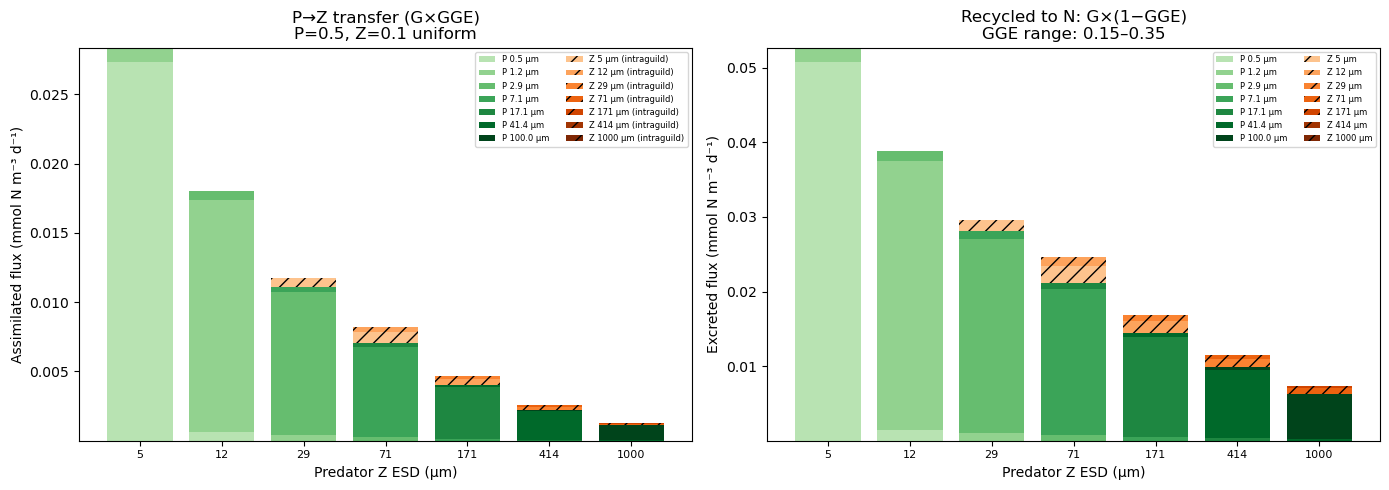

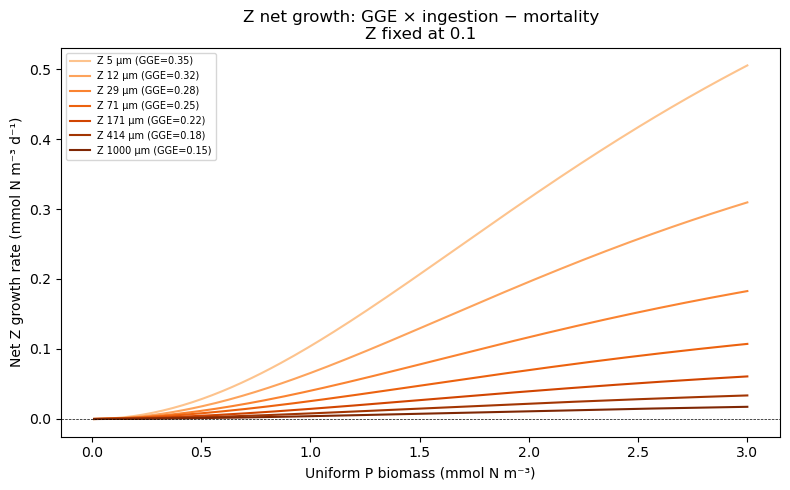

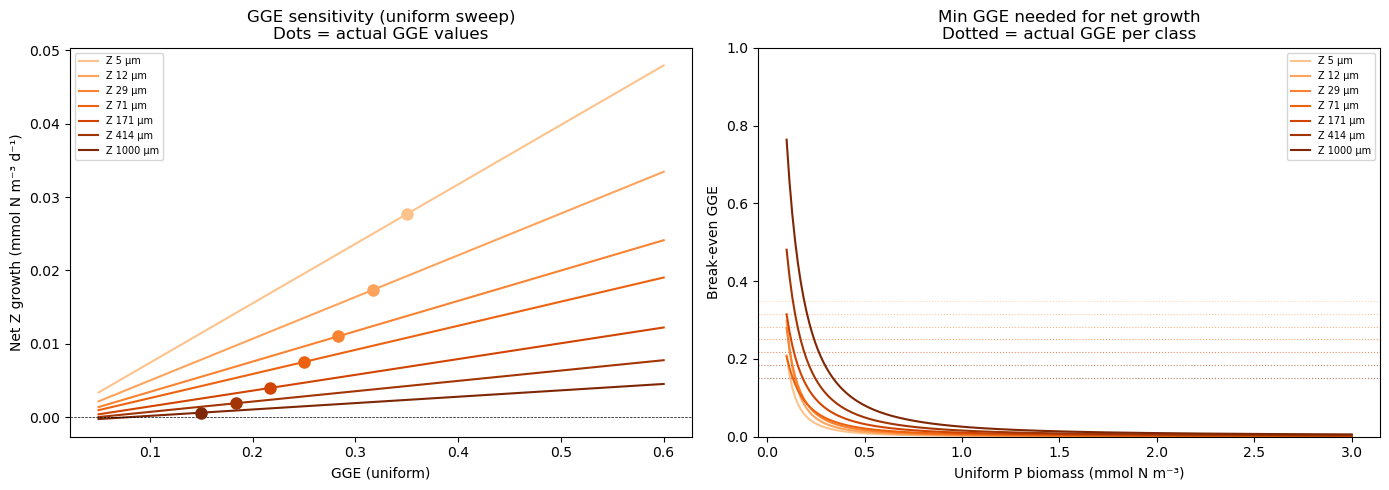

Done. Saved: fluxes_4-6_*.png


In [2]:
# =====================================================================
# PLOT 4: Effective P→Z transfer (grazing × GGE) by prey size class
# =====================================================================

from npxzxf_models import gge

P_ref = np.full(n_P, 0.5)
Z_ref = np.full(n_Z, 0.1)

G = SizebasedGrazingMatrix_Full_TypeIII.fluxes.grazing(
    resource=P_ref, consumer=Z_ref,
    phiPZ=phiPZ, Imax=I_max, KsZ=KsZ,
)

# G has shape (n_P+n_Z, n_Z) — rows are prey, columns are predators
# Assimilated portion: G_ij * gge_j
G_assim = G * gge[None, :]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4a: Stacked bar — what each Z predator assimilates from each P prey
ax = axes[0]
x = np.arange(n_Z)
bottom = np.zeros(n_Z)
for i in range(n_P):
    vals = G_assim[i, :]  # prey i → each predator
    ax.bar(x, vals, bottom=bottom, color=cmap_P[i],
           label=f'P {phyto_esd[i]:.1f} µm')
    bottom += vals

# Add intraguild contribution (Z eating Z)
for i in range(n_Z):
    vals = G_assim[n_P + i, :]
    ax.bar(x, vals, bottom=bottom, color=cmap_Z[i], hatch='//',
           label=f'Z {zoo_esd[i]:.0f} µm (intraguild)')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f'{e:.0f}' for e in zoo_esd], fontsize=8)
ax.set_xlabel('Predator Z ESD (µm)')
ax.set_ylabel('Assimilated flux (mmol N m⁻³ d⁻¹)')
ax.set_title(f'P→Z transfer (G×GGE)\nP={P_ref[0]:.1f}, Z={Z_ref[0]:.1f} uniform')
ax.legend(fontsize=6, ncol=2)

# 4b: Excretion (recycled to N) per predator
G_excreted = G * (1 - gge[None, :])
ax = axes[1]
bottom = np.zeros(n_Z)
for i in range(n_P + n_Z):
    vals = G_excreted[i, :]
    if i < n_P:
        ax.bar(x, vals, bottom=bottom, color=cmap_P[i],
               label=f'P {phyto_esd[i]:.1f} µm')
    else:
        ax.bar(x, vals, bottom=bottom, color=cmap_Z[i - n_P], hatch='//',
               label=f'Z {zoo_esd[i - n_P]:.0f} µm')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f'{e:.0f}' for e in zoo_esd], fontsize=8)
ax.set_xlabel('Predator Z ESD (µm)')
ax.set_ylabel('Excreted flux (mmol N m⁻³ d⁻¹)')
ax.set_title(f'Recycled to N: G×(1−GGE)\nGGE range: {gge.min():.2f}–{gge.max():.2f}')
ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
#plt.savefig('fluxes_4_gge_transfer.png', dpi=150)
plt.show()


# =====================================================================
# PLOT 5: Net Z growth (assimilation − mortality) vs prey availability
# =====================================================================

from npxzxf_comps import ZooQuadraticMortality

P_range = np.linspace(0.01, 3.0, 200)
Z_fixed = np.full(n_Z, 0.1)

net_growth_Z = np.zeros((len(P_range), n_Z))

for idx, P_val in enumerate(P_range):
    P_vec = np.full(n_P, P_val)

    G = SizebasedGrazingMatrix_Full_TypeIII.fluxes.grazing(
        resource=P_vec, consumer=Z_fixed,
        phiPZ=phiPZ, Imax=I_max, KsZ=KsZ,
    )

    # Assimilation per predator: gge_j * sum_i(G_ij)
    total_ingested = np.sum(G, axis=0)
    assimilation = total_ingested * gge

    # Mortality
    mort = ZooQuadraticMortality.fluxes.mortality(
        population=Z_fixed, rate=m_Z,
    )

    net_growth_Z[idx, :] = assimilation - mort

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(n_Z):
    ax.plot(P_range, net_growth_Z[:, i], color=cmap_Z[i],
            label=f'Z {zoo_esd[i]:.0f} µm (GGE={gge[i]:.2f})')

ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Uniform P biomass (mmol N m⁻³)')
ax.set_ylabel('Net Z growth rate (mmol N m⁻³ d⁻¹)')
ax.set_title(f'Z net growth: GGE × ingestion − mortality\nZ fixed at {Z_fixed[0]:.1f}')
ax.legend(fontsize=7)
plt.tight_layout()
#plt.savefig('fluxes_5_net_Z_growth.png', dpi=150)
plt.show()


# =====================================================================
# PLOT 6: GGE sensitivity — sweep GGE, show net Z growth
# =====================================================================

gge_range = np.linspace(0.05, 0.6, 50)

# Fixed prey field for this sweep
P_fixed = np.full(n_P, 0.5)
Z_fixed = np.full(n_Z, 0.1)

G_fixed = SizebasedGrazingMatrix_Full_TypeIII.fluxes.grazing(
    resource=P_fixed, consumer=Z_fixed,
    phiPZ=phiPZ, Imax=I_max, KsZ=KsZ,
)
total_ingested_per_Z = np.sum(G_fixed, axis=0)  # (n_Z,)

mort_fixed = ZooQuadraticMortality.fluxes.mortality(
    population=Z_fixed, rate=m_Z,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6a: Net growth per Z as function of uniform GGE
ax = axes[0]
for i in range(n_Z):
    net = gge_range * total_ingested_per_Z[i] - mort_fixed[i]
    ax.plot(gge_range, net, color=cmap_Z[i],
            label=f'Z {zoo_esd[i]:.0f} µm')

ax.axhline(0, color='k', lw=0.5, ls='--')
for i in range(n_Z):
    # mark the actual GGE value
    net_actual = gge[i] * total_ingested_per_Z[i] - mort_fixed[i]
    ax.plot(gge[i], net_actual, 'o', color=cmap_Z[i], ms=8, zorder=5)

ax.set_xlabel('GGE (uniform)')
ax.set_ylabel('Net Z growth (mmol N m⁻³ d⁻¹)')
ax.set_title(f'GGE sensitivity (uniform sweep)\nDots = actual GGE values')
ax.legend(fontsize=7)

# 6b: Break-even GGE per Z class vs prey level
ax = axes[1]
P_sweep = np.linspace(0.1, 3.0, 200)

for i in range(n_Z):
    breakeven_gge = np.zeros(len(P_sweep))
    for idx, P_val in enumerate(P_sweep):
        G_tmp = SizebasedGrazingMatrix_Full_TypeIII.fluxes.grazing(
            resource=np.full(n_P, P_val), consumer=Z_fixed,
            phiPZ=phiPZ, Imax=I_max, KsZ=KsZ,
        )
        ingested_i = np.sum(G_tmp, axis=0)[i]
        mort_i = mort_fixed[i]
        breakeven_gge[idx] = mort_i / (ingested_i + 1e-12)

    ax.plot(P_sweep, breakeven_gge, color=cmap_Z[i],
            label=f'Z {zoo_esd[i]:.0f} µm')
    ax.axhline(gge[i], color=cmap_Z[i], ls=':', lw=0.8, alpha=0.6)

ax.set_ylim(0, 1.0)
ax.set_xlabel('Uniform P biomass (mmol N m⁻³)')
ax.set_ylabel('Break-even GGE')
ax.set_title('Min GGE needed for net growth\nDotted = actual GGE per class')
ax.legend(fontsize=7)

plt.tight_layout()
#plt.savefig('fluxes_6_gge_sensitivity.png', dpi=150)
plt.show()

print("Done. Saved: fluxes_4-6_*.png")